In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('calories.csv')

In [3]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [5]:
df.shape

(15000, 9)

In [6]:
# histogram- for skewness

In [7]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [8]:
df['Gender'] = df['Gender'].map({'male':0,'female':1})

In [9]:
df.skew()

User_ID       0.004788
Gender       -0.014135
Age           0.473383
Height       -0.006190
Weight        0.226725
Duration      0.004751
Heart_Rate   -0.010704
Body_Temp    -0.994382
Calories      0.505371
dtype: float64

<Axes: xlabel='Calories', ylabel='Count'>

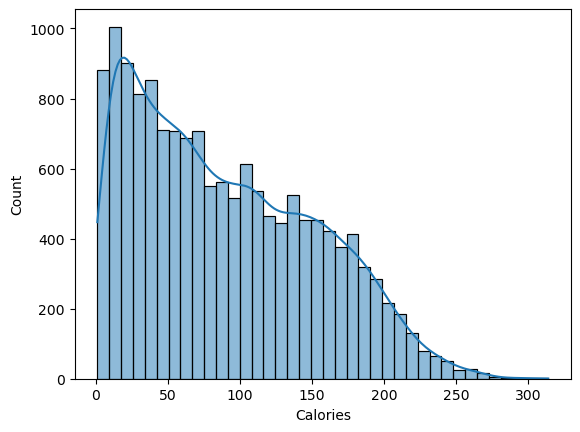

In [10]:
sns.histplot(df['Calories'],kde=True)

## Standard Scaler -> distance based algorithm 

In [11]:
X = df.drop(columns=['Calories','User_ID'],axis=1)
y = df['Calories']

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42) 

## Hyperparameter Tuning

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [14]:
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[2,5,10], 
    'min_samples_split':[2,5,10], 
    'min_samples_leaf':[1,2,4]
}

In [15]:
randomized = RandomizedSearchCV(
    estimator=RandomForestRegressor(n_estimators=300),
    param_distributions = param_grid,
    n_iter=10,
    cv=5, 
    n_jobs= -1 ,
    verbose=1 
) 


In [16]:
randomized.fit(X_train,y_train) 

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestR...stimators=300)
,param_distributions,"{'max_depth': [2, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [17]:
randomized.best_score_

np.float64(0.9962673552854678)

In [18]:
# Random forest model 
RFModel = RandomForestRegressor(max_depth=10, n_estimators=300)

In [19]:
# 1- Train 
RFModel.fit(X_train,y_train) # seen values where we train the model 

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
# 2- Predictions 
y_pred = RFModel.predict(X_test) # unseen value where we test the model 
y_pred 

array([169.54175445, 194.45323783,  52.73787248, ...,  15.02868136,
       165.82254247,  72.57610287], shape=(4950,))

In [21]:
# 3- Evaluation
from sklearn.metrics import confusion_matrix, r2_score, mean_absolute_error

In [22]:
# Testing 
r2_score(y_test , y_pred)*100

99.6695425042307

In [23]:
r2_score(y_train,RFModel.predict(X_train))*100

99.85674833226234

In [24]:
# Mean absolute error 
mean_absolute_error(y_test,y_pred)

2.396779863701091